In [1]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.special import exp1

def theis_head(x, y, t, Q, T, S, psi0, cx, cy):
    r2 = (x - cx) ** 2 + (y - cy) ** 2
    if t <= 0.0 or not np.isfinite(psi0):
        return psi0
    u = (r2 * S) / (4.0 * T * t)
    drawdown = (Q / (4.0 * np.pi * T)) * exp1(u)
    return psi0 - drawdown

def theis_drawdown(r2, t, Q, T, S):
    u = (r2 * S) / (4.0 * T * t)
    return (Q / (4.0 * np.pi * T)) * exp1(u)


def compute_errors(folder, file_glob, label):
    file_pattern = os.path.join(folder, file_glob)

    # Step 1: Identify t=0 (or smallest t) file
    min_time = float('inf')
    t0_path = None
    for fpath in sorted(glob.glob(file_pattern)):
        df = pd.read_csv(fpath, nrows=1)
        t = df['Time'].iloc[0]
        if t < min_time:
            min_time = t
            t0_path = fpath

    if t0_path is None:
        raise RuntimeError("No valid CSV file found to initialize psi0 map.")

    df0 = pd.read_csv(t0_path)
    p0_x = np.round(df0['Points:0'].values * 1e6).astype(int)
    p0_y = np.round(df0['Points:1'].values * 1e6).astype(int)
    psi0_vals = df0['pressure_head'].values
    initial_head_map = dict(zip(zip(p0_x, p0_y), psi0_vals))

    results = []
    print(f"\n==== Results for {label} ====")
    print(f"{'Time (s)':<12} {'L2 Error':<14} {'Relative Error (%)':<20}")

    for fpath in sorted(glob.glob(file_pattern)):
        df = pd.read_csv(fpath)
        time = df['Time'].iloc[0]

        x = df['Points:0'].values
        y = df['Points:1'].values
        r = np.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
        mask = (r > exclude_r_min) & (r < exclude_r_max)
        if not np.any(mask):
            continue

        x_valid = x[mask]
        y_valid = y[mask]
        r2_valid = (x_valid - center_x) ** 2 + (y_valid - center_y) ** 2
        num_valid = df['pressure_head'].values[mask]

        if np.isclose(time, 0.0):
            psi_theis = num_valid
        else:
            keys = list(zip(np.round(x_valid * 1e6).astype(int), np.round(y_valid * 1e6).astype(int)))
            psi0 = np.array([initial_head_map.get(k, np.nan) for k in keys])
            drawdown = theis_drawdown(r2_valid, time, Q, T, S)
            psi_theis = psi0 - drawdown

        valid = np.isfinite(psi_theis)
        numerical = num_valid[valid]
        analytical = psi_theis[valid]

        if len(numerical) == 0:
            continue
        l2_error = np.sqrt(np.mean((numerical - analytical) ** 2))
        relative_error = l2_error / np.sqrt(np.mean(analytical ** 2))
        results.append((time, l2_error, relative_error))
        #relative_error = np.sqrt(np.mean((numerical - analytical) ** 2)) / np.sqrt(np.mean(analytical ** 2))
        #results.append((time, relative_error))

        #print(f"{time:<10.2f} {relative_error:<20.6f}")
        print(f"{time:<10.2f} {l2_error:<14.6f} {relative_error * 100:<20.6f}")

    return results



C:\Users\12254\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\12254\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
C:\Users\12254\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [13]:
import os

center_x, center_y = 100.0, 100.0
exclude_r_min = 0.2
exclude_r_max = 90.0
Q = 1e-3
T = 5e-4
S = 1e-4
#psi0 = 16.0

errors = {}
errors['ref_0'] = compute_errors("FCT_convergence_dbc_again_2/ref_0_again/data_3d", "ref_0_*.csv", "he_8_0")
errors['ref_1'] = compute_errors("FCT_convergence_dbc_again_2/ref_6/data_3d", "ref_6_*.csv", "he_6_0")
errors['ref_2'] = compute_errors("FCT_convergence_dbc_again_2/ref_1/data_3d", "ref_1_*.csv", "he_4_0")

#errors['ref_new'] = compute_errors("FCT_convergence_dbc_again_2/ref_new/data_3d", "ref_new_*.csv", "he_12_0")
#errors['ref_1'] = compute_errors("FCT_convergence_dbc_again_2/ref_neg_1/data_3d_1", "ref_neg_1_*.csv", "he_16_0")
#errors['ref_10'] = compute_errors("FCT_convergence_dbc_again_2/ref_10/data_3d", "ref_10_*.csv", "he_10_0")




==== Results for he_8_0 ====
Time (s)     L2 Error       Relative Error (%)  
0.00       0.000000       0.000000            
0.00       0.000000       0.000000            
1.80       6.784034       128.460077          
2.00       6.784045       128.622124          
2.20       6.783869       128.764762          
2.40       6.783759       128.895580          
2.60       6.783642       129.015312          
2.80       6.783705       129.129164          
3.00       6.783506       129.230015          
3.20       6.783552       129.328579          
3.40       6.783414       129.417523          
3.60       6.783439       129.504187          
0.20       6.794122       125.188269          
3.80       6.783443       129.585655          
4.00       6.783312       129.660212          
4.20       6.783387       129.734836          
4.40       6.783343       129.803675          
4.60       6.783361       129.870499          
4.80       6.783280       129.932511          
5.00       6.783247       12

33.00      5.695386       105.983544          
33.20      5.695365       105.994072          
33.40      5.695350       106.004645          
33.60      5.695334       106.015154          
3.20       5.695904       101.856538          
33.80      5.695412       106.027335          
34.00      5.695398       106.037759          
34.20      5.695373       106.047905          
34.40      5.695343       106.057892          
34.60      5.695394       106.069334          
34.80      5.695369       106.079306          
35.00      5.695332       106.089002          
35.20      5.695403       106.100646          
35.40      5.695370       106.110288          
35.60      5.695406       106.121161          
3.40       5.695838       101.961267          
35.80      5.695367       106.130578          
36.00      5.695433       106.141902          
36.20      5.695388       106.151113          
36.40      5.695341       106.160228          
36.60      5.695376       106.170812          
36.80      5.

2.60       4.280993       55.292691           
27.80      4.281037       57.493863           
28.00      4.281064       57.501146           
28.20      4.281049       57.507822           
28.40      4.281063       57.514848           
28.60      4.281044       57.521376           
28.80      4.281060       57.528335           
29.00      4.281036       57.534703           
29.20      4.281047       57.541496           
29.40      4.281064       57.548344           
29.60      4.281038       57.554556           
2.80       4.281011       55.359417           
29.80      4.281045       57.561168           
30.00      4.281066       57.567934           
30.20      4.281029       57.573873           
30.40      4.281043       57.580462           
30.60      4.281053       57.586959           
30.80      4.281050       57.593238           
31.00      4.281056       57.599595           
31.20      4.281062       57.605919           
31.40      4.281068       57.612195           
31.60      4.

In [18]:
def compute_convergence_rates_relative(errors_dict, he_dict):
    # 1. Find common time steps
    common_times = set(t for t, _, _ in next(iter(errors_dict.values())))
    for v in errors_dict.values():
        common_times &= set(t for t, _, _ in v)
    common_times = sorted(common_times)

    # 2. Sort refinements by mesh size (coarse to fine)
    sorted_refs = sorted(he_dict.items(), key=lambda kv: kv[1], reverse=True)
    sorted_keys = [k for k, _ in sorted_refs]

    # Header row
    print(f"\n{'Time (s)':<10}", end='')
    for k in sorted_keys:
        print(f"Rel. Err ({k})".ljust(18), end='')
    for i in range(len(sorted_keys) - 1):
        print(f"Rate ({sorted_keys[i]}→{sorted_keys[i+1]})".ljust(28), end='')
    print()

    # 3. Compute and print errors and convergence rates
    for t in common_times:
        print(f"{t:<10.2f}", end='')

        rel_errors = []
        for k in sorted_keys:
            err_tuple = next(((time, _, rel) for time, _, rel in errors_dict[k] if time == t), None)
            rel = err_tuple[2] if err_tuple else np.nan
            rel_errors.append(rel)
            print(f"{rel:<18.6f}", end='')

        for i in range(len(rel_errors) - 1):
            e1, e2 = rel_errors[i], rel_errors[i + 1]
            h1, h2 = he_dict[sorted_keys[i]], he_dict[sorted_keys[i + 1]]
            if e1 > 0 and e2 > 0:
                rate = np.log(e1 / e2) / np.log(h1 / h2)
                print(f"{rate:<28.6f}", end='')
            else:
                print(f"{'nan':<28}", end='')

        print()


In [39]:
filtered_errors = {
    'ref_0': errors['ref_0'],
    'ref_1': errors['ref_1'],
    'ref_2': errors['ref_2']
}

filtered_he_values = {
    'ref_0': 8,
    'ref_1': 6,
    'ref_2': 4

    
    #'ref_neg_2': 32.0,
#    'ref_neg_1': 16.0,
#    'ref_0': 8.0,
    
}

In [24]:
compute_convergence_rates_relative(filtered_errors, filtered_he_values)


Time (s)  Rel. Err (ref_0)  Rel. Err (ref_1)  Rel. Err (ref_2)  Rate (ref_0→ref_1)          Rate (ref_1→ref_2)          
0.00      0.000000          0.000000          0.000000          nan                         nan                         
0.00      0.000000          0.000000          0.000000          nan                         nan                         
0.20      1.251883          0.972638          0.530839          0.877328                    1.493481                    
0.40      1.261885          0.983487          0.536619          0.866436                    1.494124                    
0.60      1.267960          0.990114          0.540073          0.859787                    1.494867                    
0.80      1.272315          0.994886          0.542547          0.854990                    1.495452                    
1.00      1.275686          0.998633          0.544485          0.851121                    1.495927                    
1.20      1.278458          1.0

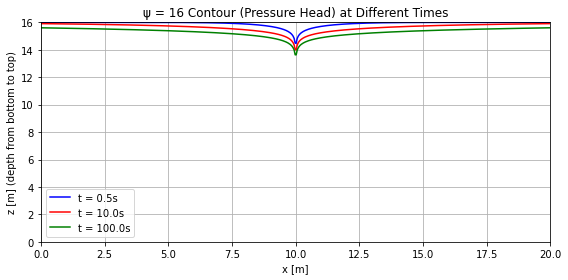

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import exp1

# Parameters
Q = 1e-3
T = 5e-4
S = 1e-4
psi0 = 16.0
height = 16.0
center_x = 10.0

def theis_drawdown(r2, t, Q, T, S):
    u = (r2 * S) / (4.0 * T * t)
    return (Q / (4.0 * np.pi * T)) * exp1(u)

def compute_psi16_z_profile(x_range, t, target_psi=16.0):
    z_vals = []
    for x in x_range:
        r2 = (x - center_x) ** 2
        if t <= 0:
            drawdown = 0.0
        else:
            drawdown = theis_drawdown(r2, t, Q, T, S)
        psi = psi0 - drawdown
        z = psi  # Since ψ = pressure head, z = ψ in this case
        z_vals.append(z)
    return np.array(z_vals)

# Horizontal profile
x_vals = np.linspace(0.0, 20.0, 500)
times = [0.5, 10.0, 100.0]
colors = ['blue', 'red', 'green']

# Plot
plt.figure(figsize=(8, 4))
for t, color in zip(times, colors):
    z_vals = compute_psi16_z_profile(x_vals, t)
    plt.plot(x_vals, z_vals, label=f't = {t:.1f}s', color=color)

plt.xlabel("x [m]")
plt.ylabel("z [m] (depth from bottom to top)")
plt.title("ψ = 16 Contour (Pressure Head) at Different Times")
plt.xlim(0, 20)
plt.ylim(0, 16)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [31]:
def compute_errors(folder, file_glob, label):
    file_pattern = os.path.join(folder, file_glob)

    # Step 1: Identify t=0 (or smallest t) file
    min_time = float('inf')
    t0_path = None
    for fpath in sorted(glob.glob(file_pattern)):
        df = pd.read_csv(fpath, nrows=1)
        t = df['Time'].iloc[0]
        if t < min_time:
            min_time = t
            t0_path = fpath

    if t0_path is None:
        raise RuntimeError("No valid CSV file found to initialize psi0 map.")

    df0 = pd.read_csv(t0_path)
    p0_x = np.round(df0['Points:0'].values * 1e6).astype(int)
    p0_y = np.round(df0['Points:1'].values * 1e6).astype(int)
    psi0_vals = df0['pressure_head'].values
    initial_head_map = dict(zip(zip(p0_x, p0_y), psi0_vals))

    results = {}
    print(f"\n==== Results for {label} ====")
    print(f"{'Time (s)':<12} {'Relative Error (%)':<20}")

    for fpath in sorted(glob.glob(file_pattern)):
        df = pd.read_csv(fpath)
        time = df['Time'].iloc[0]

        x = df['Points:0'].values
        y = df['Points:1'].values
        r = np.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
        mask = (r > exclude_r_min) & (r < exclude_r_max)
        if not np.any(mask):
            continue

        x_valid = x[mask]
        y_valid = y[mask]
        r2_valid = (x_valid - center_x) ** 2 + (y_valid - center_y) ** 2
        num_valid = df['pressure_head'].values[mask]

        if np.isclose(time, 0.0):
            psi_theis = num_valid
        else:
            keys = list(zip(np.round(x_valid * 1e6).astype(int), np.round(y_valid * 1e6).astype(int)))
            psi0 = np.array([initial_head_map.get(k, np.nan) for k in keys])
            drawdown = theis_drawdown(r2_valid, time, Q, T, S)
            psi_theis = psi0 - drawdown

        valid = np.isfinite(psi_theis)
        numerical = num_valid[valid]
        analytical = psi_theis[valid]

        if len(numerical) == 0:
            continue

        relative_error = np.sqrt(np.mean((numerical - analytical) ** 2)) / np.sqrt(np.mean(analytical ** 2))
        results[time] = relative_error

        print(f"{time:<10.2f} {relative_error:<20.6f}")

    return results


In [32]:
filtered_errors = {
    'ref_0': errors['ref_0'],
    'ref_1': errors['ref_1'],
    'ref_2': errors['ref_2']
}

In [37]:
def plot_relative_error_vs_he(errors_dict, he_dict, target_time, loglog=True):
    """
    Plot relative error vs. mesh size (he) at a specific target time.

    Parameters:
    - errors_dict: dict with keys as refinement levels, values as [(time, _, rel_error), ...]
    - he_dict: dict mapping refinement keys to mesh size he
    - target_time: float, time at which to extract relative error
    - loglog: bool, whether to use log-log scale
    """
    he_vals = []
    rel_errors = []

    for k in he_dict:
        he = he_dict[k]
        data = errors_dict[k]
        for t, _, rel in data:
            if np.isclose(t, target_time):
                he_vals.append(he)
                rel_errors.append(rel)
                break  # Found matching time, skip remaining

    # Sort by mesh size
    he_vals, rel_errors = zip(*sorted(zip(he_vals, rel_errors), reverse=True))

    plt.figure(figsize=(8, 6))
    if loglog:
        plt.loglog(he_vals, rel_errors, marker='o', linestyle='-', label=f"t = {target_time}")
    else:
        plt.plot(he_vals, rel_errors, marker='o', linestyle='-', label=f"t = {target_time}")

    for h, err in zip(he_vals, rel_errors):
        plt.text(h, err, f"{err:.2e}", fontsize=8, ha='right', va='bottom')

    plt.xlabel("Mesh Size $h_e$")
    plt.ylabel("Relative $L_2$ Error")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.title(f"Relative $L_2$ Error vs. Mesh Size at t = {target_time}")
    plt.tight_layout()
    plt.legend()
    plt.show()


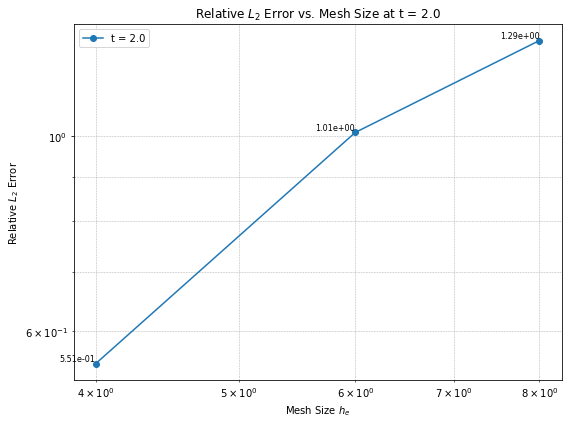

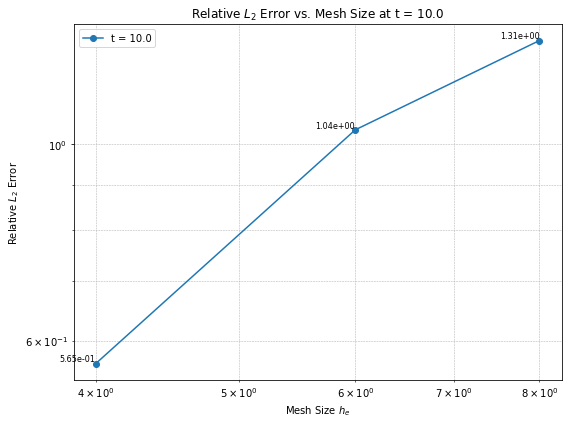

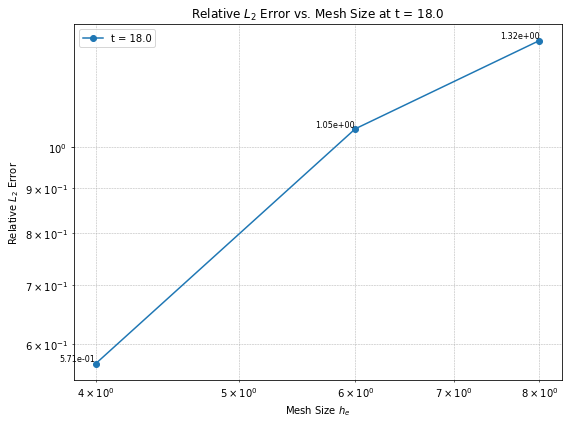

In [41]:
plot_relative_error_vs_he(filtered_errors, filtered_he_values, target_time=2.0)
plot_relative_error_vs_he(filtered_errors, filtered_he_values, target_time=10.0)
plot_relative_error_vs_he(filtered_errors, filtered_he_values, target_time=18.0)
